# LSTM Training

Notebook ini melatih LSTM decoder dengan **6 variasi**:
- 3 variasi jumlah layer: 1, 2, 3
- 2 variasi ukuran hidden state: 128, 512

**Arsitektur:** Pre-inject (Show and Tell, Vinyals et al. 2015)  
**Loss:** Sparse Categorical Crossentropy  
**Optimizer:** Adam

In [26]:
import os, sys, json, time, pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

from src.lstm.train_keras import build_lstm_decoder, train, build_dataset, EMBED_DIM
from src.shared.caption_utils import load_vocabulary, clean_caption, encode_caption

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Feature & Vocabulary

In [27]:
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(6):
        if (cur / 'src').exists() and (cur / 'requirements.txt').exists():
            return cur
        cur = cur.parent
    return start.resolve()

def normalize_id(x: str) -> str:
    return Path(x).stem

ROOT = find_repo_root(Path.cwd())

FEATURES_PATH = ROOT / 'features' / 'flickr8k_features.npy'
FEAT_IDX_PATH = ROOT / 'features' / 'flickr8k_idx.json'
VOCAB_PATH    = ROOT / 'features' / 'vocab.json'
CAPTIONS_TXT  = ROOT / 'data' / 'flickr8k' / 'captions.txt'

missing = [p for p in (FEATURES_PATH, FEAT_IDX_PATH, VOCAB_PATH, CAPTIONS_TXT) if not p.exists()]
if missing:
    missing_list = '\n'.join(f'- {p}' for p in missing)
    raise FileNotFoundError(
        'File(s) missing:\n' + missing_list +
        "\n\nRun 05_Feature_extraction.ipynb and 06_Caption_preprocessing.ipynb to generate features/vocab."
    )

features = np.load(FEATURES_PATH)
with open(FEAT_IDX_PATH) as f:
    img_idx_raw = json.load(f)

img_idx = {normalize_id(k): int(v) for k, v in img_idx_raw.items()}
image_ids = [img_id for img_id, _ in sorted(img_idx.items(), key=lambda x: x[1])]
if len(image_ids) != features.shape[0]:
    raise ValueError(f'Jumlah feature ({features.shape[0]}) tidak sama dengan jumlah image_ids ({len(image_ids)}).')

FEATURE_DIM = features.shape[1]
print(f'Features shape: {features.shape}')

vocab = load_vocabulary(VOCAB_PATH)
VOCAB_SIZE = len(vocab)
print(f'Vocab size: {VOCAB_SIZE}')

Features shape: (8091, 2048)
Vocab size: 7684


## 2. Prepare Dataset

In [28]:
MAX_LEN = 30

captions_dict = {}
with open(CAPTIONS_TXT) as f:
    for line in f:
        line = line.strip()
        if not line or line.lower().startswith('image'):
            continue
        parts = line.split(',', 1)
        if len(parts) < 2:
            continue
        img_file, caption = parts
        img_id = normalize_id(img_file.split('#')[0].strip())
        clean  = clean_caption(caption)
        captions_dict.setdefault(img_id, []).append(clean)

print(f'Total images with captions: {len(captions_dict)}')

captions_encoded = {}
for img_id, caps in captions_dict.items():
    captions_encoded[img_id] = [
        encode_caption(c, vocab, MAX_LEN) for c in caps
    ]

common_ids = [img_id for img_id in image_ids if img_id in captions_encoded]
if not common_ids:
    raise ValueError('Tidak ada image_id yang cocok antara features dan captions.')

train_ids = common_ids[:6000]
val_ids   = common_ids[6000:7000]

train_captions = {k: captions_encoded[k] for k in train_ids}
val_captions   = {k: captions_encoded[k] for k in val_ids}

print(f'Common images: {len(common_ids)}')
print(f'Train images: {len(train_captions)}, Val images: {len(val_captions)}')

Total images with captions: 8091
Common images: 8091
Train images: 6000, Val images: 1000


In [29]:
if not train_captions or not val_captions:
    raise ValueError('Train/Val captions kosong. Pastikan file fitur & caption sudah benar.')

train_ds = build_dataset(features, image_ids, train_captions,
                          batch_size=64, shuffle=True)
val_ds   = build_dataset(features, image_ids, val_captions,
                          batch_size=64, shuffle=False)

print('Datasets siap.')

for (feat_b, cap_b), tgt_b in train_ds.take(1):
    print('Feature batch shape:', feat_b.shape)
    print('Caption input batch shape:', cap_b.shape)
    print('Target batch shape:', tgt_b.shape)

Datasets siap.
Feature batch shape: (64, 2048)
Caption input batch shape: (64, 29)
Target batch shape: (64, 29)


2026-05-12 22:15:16.372701: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 3. Training 6 Variasi

In [30]:
CONFIGS = [
    {'name': 'lstm-1layer-128', 'num_lstm_layers': 1, 'lstm_units': 128},
    {'name': 'lstm-2layer-128', 'num_lstm_layers': 2, 'lstm_units': 128},
    {'name': 'lstm-3layer-128', 'num_lstm_layers': 3, 'lstm_units': 128},
    {'name': 'lstm-1layer-512', 'num_lstm_layers': 1, 'lstm_units': 512},
    {'name': 'lstm-2layer-512', 'num_lstm_layers': 2, 'lstm_units': 512},
    {'name': 'lstm-3layer-512', 'num_lstm_layers': 3, 'lstm_units': 512},
]

histories = {}
os.makedirs('../../models/lstm', exist_ok=True)

for cfg in CONFIGS:
    sep = '=' * 60
    print(f'\n{sep}\nTraining: {cfg["name"]}\n{sep}')
    t0 = time.time()

    model = build_lstm_decoder(
        vocab_size=VOCAB_SIZE,
        feature_dim=FEATURE_DIM,
        embed_dim=EMBED_DIM,
        lstm_units=cfg['lstm_units'],
        num_lstm_layers=cfg['num_lstm_layers'],
        max_len=MAX_LEN - 1,
    )
    model.summary()

    hist = train(
        model, train_ds, val_ds,
        model_name=cfg['name'],
        epochs=20,
        save_path='../../models/lstm/',
    )
    histories[cfg['name']] = hist.history

    elapsed = time.time() - t0
    print(f'Selesai dalam {elapsed/60:.1f} menit')

with open('../../models/lstm/histories.pkl', 'wb') as f:
    pickle.dump(histories, f)


Training: lstm-1layer-128


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ feature             │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_proj (Dense)   │ (None, 256)       │    524,544 │ feature[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption             │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_expand         │ (None, 1, 256)    │          0 │ feat_proj[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 29, 256)   │  1,967,104 │ caption[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_seq            │ (None, 30, 256)   │          0 │ feat_expand[0][0… │
│ (Concatenate)       │                   │            │ token_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ (None, 30, 128)   │    197,120 │ full_seq[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 30, 7684)  │    991,236 │ lstm_0[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_feat_pos       │ (None, 29, 7684)  │          0 │ output_dense[0][… │
│ (Lambda)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,680,004 (14.04 MB)

 Trainable params: 3,680,004 (14.04 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ feature             │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_proj (Dense)   │ (None, 256)       │    524,544 │ feature[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption             │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_expand         │ (None, 1, 256)    │          0 │ feat_proj[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 29, 256)   │  1,967,104 │ caption[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_seq            │ (None, 30, 256)   │          0 │ feat_expand[0][0… │
│ (Concatenate)       │                   │            │ token_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ (None, 30, 512)   │  1,574,912 │ full_seq[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 30, 512)   │  2,099,200 │ lstm_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 30, 512)   │  2,099,200 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 30, 7684)  │  3,941,892 │ lstm_2[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_feat_pos       │ (None, 29, 7684)  │          0 │ output_dense[0][… │
│ (Lambda)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,206,852 (46.57 MB)

 Trainable params: 12,206,852 (46.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - loss: 2.8258
Epoch 1: val_loss improved from inf to 1.95708, saving model to ../../models/lstm/lstm-3layer-512.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 162s 338ms/step - loss: 2.8248 - val_loss: 1.9571
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - loss: 1.8157
Epoch 2: val_loss improved from 1.95708 to 1.68316, saving model to ../../models/lstm/lstm-3layer-512.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 337ms/step - loss: 1.8155 - val_loss: 1.6832
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 1.5807
Epoch 3: val_loss improved from 1.68316 to 1.56819, saving model to ../../models/lstm/lstm-3layer-512.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 159s 339ms/step - loss: 1.5807 - val_loss: 1.5682
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - loss: 1.4459
Epoch 4: val_loss improved from 1.56819 to 1.47228, saving model to ../../models/lstm/lstm-3layer-512.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 334ms

## 4. Plot Training & Validation Loss

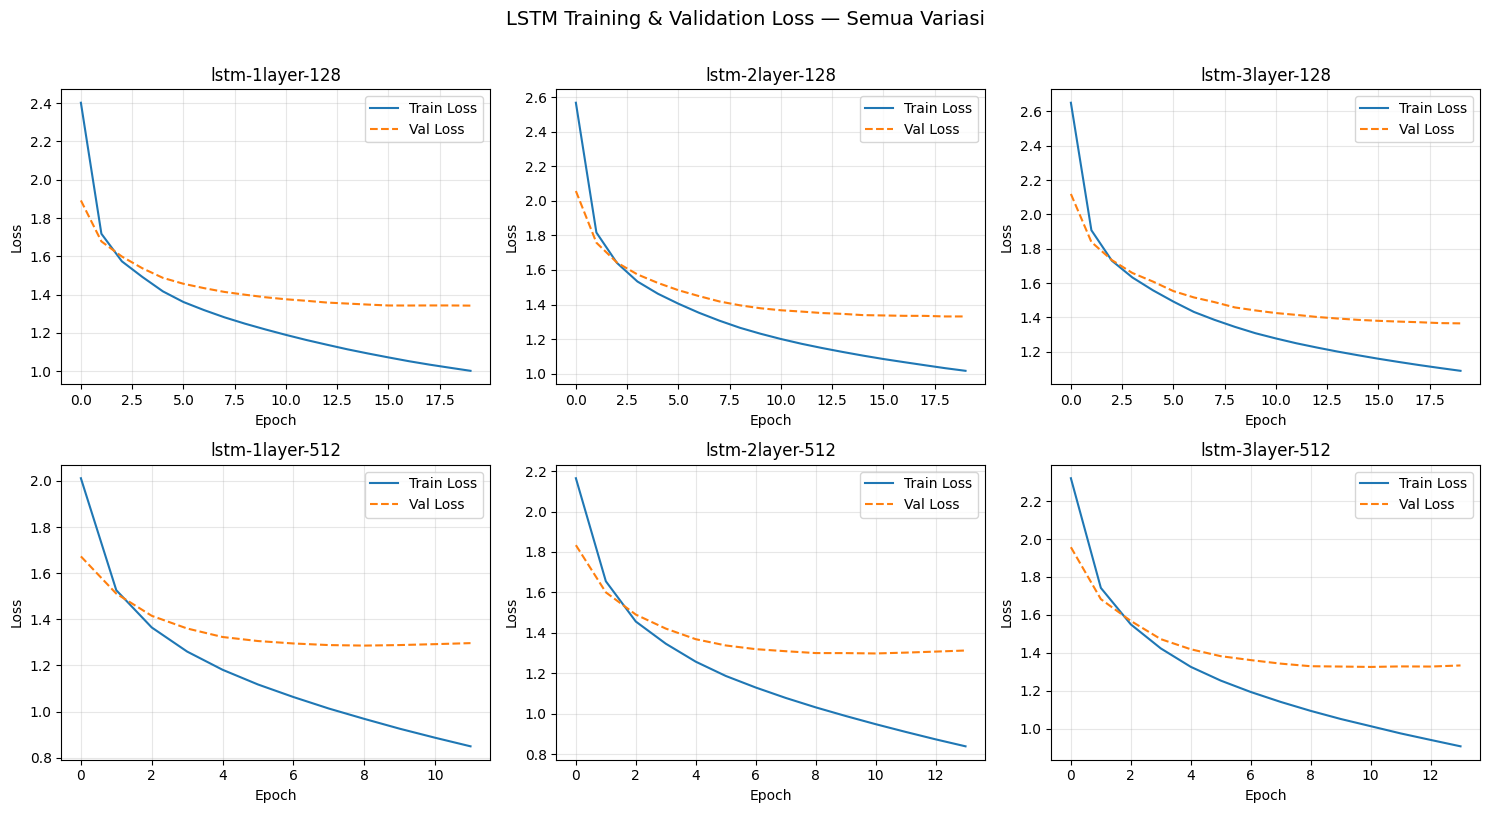

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, cfg in zip(axes, CONFIGS):
    hist = histories[cfg['name']]
    ax.plot(hist['loss'],     label='Train Loss')
    ax.plot(hist['val_loss'], label='Val Loss', linestyle='--')
    ax.set_title(cfg['name'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('LSTM Training & Validation Loss — Semua Variasi', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../models/lstm/training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Ringkasan Model

Tabel parameter count tiap variasi.

In [32]:
print(f"{'Variasi':<22} {'Layers':<8} {'Units':<8} {'Best Val Loss':<16} {'Epochs'}")
print('-' * 65)
for cfg in CONFIGS:
    hist = histories[cfg['name']]
    best_val = min(hist['val_loss'])
    n_epochs  = len(hist['loss'])
    print(f"{cfg['name']:<22} {cfg['num_lstm_layers']:<8} {cfg['lstm_units']:<8} {best_val:<16.4f} {n_epochs}")

Variasi                Layers   Units    Best Val Loss    Epochs
-----------------------------------------------------------------
lstm-1layer-128        1        128      1.3425           20
lstm-2layer-128        2        128      1.3313           20
lstm-3layer-128        3        128      1.3647           20
lstm-1layer-512        1        512      1.2860           12
lstm-2layer-512        2        512      1.2978           14
lstm-3layer-512        3        512      1.3257           14
